## Model Evaluation 

In [ ]:
Generate the confusion matrix and classification for the DNN model

In [1]:
import os
import random

import numpy as np
import itertools

import matplotlib.pyplot as plt
import seaborn as sns
from skimage.segmentation import mark_boundaries

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import load_model

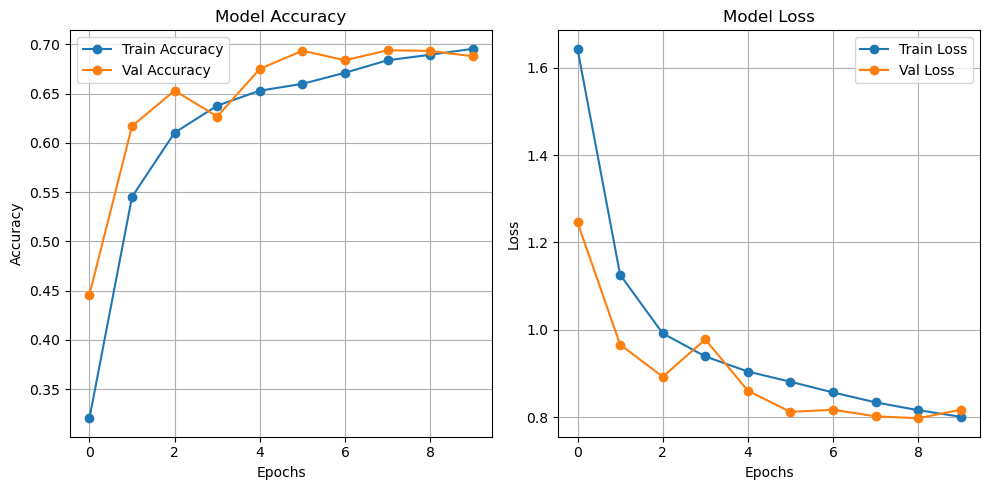

In [4]:
import matplotlib.pyplot as plt
import pickle
from tensorflow.keras.models import load_model

# Load the best tuned model
model = load_model('best_tuned_model.h5')

# Load the training history
with open('history.pkl', 'rb') as f:
    history = pickle.load(f)

# Plotting
plt.figure(figsize=(10, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history['val_accuracy'], marker='o', label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history['loss'], marker='o', label='Train Loss')
plt.plot(history['val_loss'], marker='o', label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png')  # Save the plot as an image
plt.show()

In [ ]:
i am facing an error in ImageDataGenerator.

In [6]:
# Assuming base_dir and image dimensions used during training
from tensorflow.keras.preprocessing.image import ImageDataGenerator
base_dir = r"C:\Users\nidhi\Downloads\model_dataset\model_dataset"  
img_height, img_width = 48, 48
batch_size = 32

# ImageDataGenerator setup
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_data = datagen.flow_from_directory(
    base_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # Important for correct mapping of predictions
)

val_data.reset()

# Predictions
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Found 9999 images belonging to 5 classes.


C:\Users\nidhi\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step
Confusion Matrix:
 [[1191  186   75  392  156]
 [  14 1790  172   19    5]
 [  22  613 1313   31   21]
 [ 253  108   69 1487   83]
 [ 394   80  103  325 1097]]


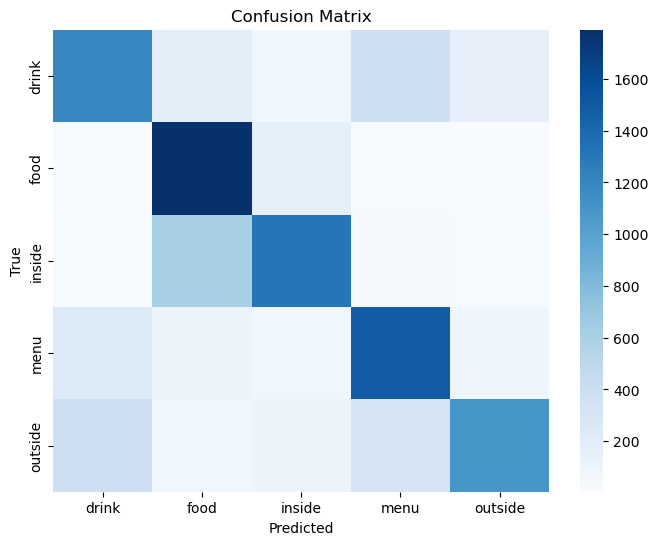

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [8]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

       drink       0.64      0.60      0.61      2000
        food       0.64      0.90      0.75      2000
      inside       0.76      0.66      0.70      2000
        menu       0.66      0.74      0.70      2000
     outside       0.81      0.55      0.65      1999

    accuracy                           0.69      9999
   macro avg       0.70      0.69      0.68      9999
weighted avg       0.70      0.69      0.68      9999



In [ ]:
plotted multi-class ROC curves and computed AUC scores for each class. 

In [9]:
from tensorflow.keras.utils import to_categorical

# ROC-AUC Score
y_true_bin = to_categorical(y_true, num_classes=len(class_names))
auc_score = roc_auc_score(y_true_bin, y_pred_probs, multi_class='ovr')
print(f"Multi-Class AUC Score: {auc_score:.4f}")

Multi-Class AUC Score: 0.9194


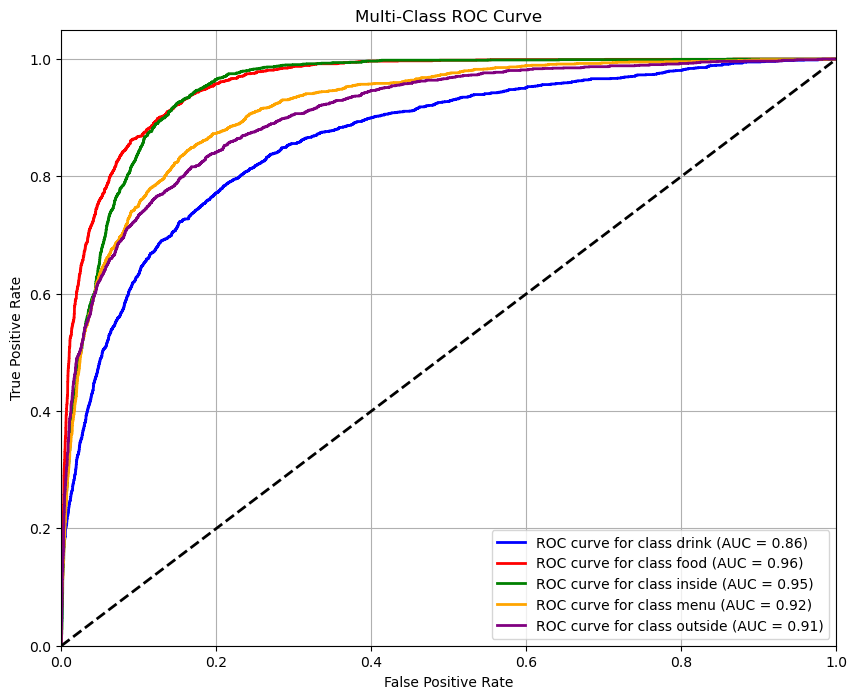

In [10]:
from sklearn.metrics import auc
from itertools import cycle  
# ROC Curve per class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = len(class_names)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve for class {list(class_names)[i]} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()